In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')

In [7]:
# --------------------------------------------------------
# 1) Forward Kinematics for 2-DOF Planar Robot
# --------------------------------------------------------
def forward_kinematics(theta1, theta2, l1=1.0, l2=1.0):
    """
    Given joint angles theta1, theta2 (in radians),
    and link lengths l1, l2,
    returns the (x,y) of the elbow and end-effector.
    """
    # Elbow position
    x_elbow = l1 * np.cos(theta1)
    y_elbow = l1 * np.sin(theta1)

    # End-effector position
    x_ee = x_elbow + l2 * np.cos(theta1 + theta2)
    y_ee = y_elbow + l2 * np.sin(theta1 + theta2)

    return (x_elbow, y_elbow, x_ee, y_ee)


In [8]:
# --------------------------------------------------------
# 2) Generate a trajectory in joint space
# --------------------------------------------------------
def generate_joint_trajectory(start_angles, end_angles, steps=20, noise_level=0.1):
    """
    Linearly interpolate between start_angles and end_angles
    in joint space over 'steps' time steps.
    Returns an array of shape (steps, 2) for (theta1, theta2).
    """
    start_angles = np.array(start_angles)
    end_angles = np.array(end_angles)

    trajectory = []
    for t in range(steps):
        alpha = t / (steps - 1)  # goes from 0 to 1
        current_angles = (1 - alpha) * start_angles + alpha * end_angles

        # Add noise to both theta1 and theta2
        noise = np.random.normal(scale=noise_level, size=2)
        current_angles += noise

        trajectory.append(current_angles)

    return np.array(trajectory)  # shape: (steps, 2)

In [15]:
# --------------------------------------------------------
# 3) Create partial & full trajectories for multiple targets
# --------------------------------------------------------
def create_dataset(target_angle_sets,
                   start_angles=(0.0, 0.0),
                   steps=20,
                   partial_ratio=0.5,
                   num_trajectories_per_target=3, noise_level=0.1):
    """
    Generates multiple full and partial trajectories for a 2-DOF arm.
    - target_angle_sets: list of (theta1, theta2) for different targets
    - start_angles: initial angles for each trajectory
    - steps: number of discrete steps in a full trajectory
    - partial_ratio: fraction (0 < partial_ratio < 1) to truncate for partial
    - num_trajectories_per_target: how many times to repeat each target
      (optionally add noise if you want variety)

    Returns a DataFrame with columns:
    ['trajectory_id', 'time_step', 'theta1', 'theta2',
     'x_elbow', 'y_elbow', 'x_ee', 'y_ee',
     'label', 'is_partial']
    """
    data_records = []
    trajectory_id = 0

    for target_name, (t1_target, t2_target) in target_angle_sets.items():
        for _ in range(num_trajectories_per_target):
            # (Optional) random noise if you want variety in start or end:
            # e.g. t1_target_noisy = t1_target + np.random.normal(0, 0.1)
            # (Here we keep it simple and use the exact angles)

            # Generate FULL trajectory from start to target
            joint_traj_full = generate_joint_trajectory(start_angles,
                                                        (t1_target, t2_target),
                                                        steps=steps, noise_level=noise_level)

            # Store FULL trajectory data
            for t_idx, (theta1, theta2) in enumerate(joint_traj_full):
                x_elbow, y_elbow, x_ee, y_ee = forward_kinematics(theta1, theta2)
                data_records.append({
                    'trajectory_id': trajectory_id,
                    'time_step': t_idx,
                    'theta1': theta1,
                    'theta2': theta2,
                    'x_elbow': x_elbow,
                    'y_elbow': y_elbow,
                    'x_ee': x_ee,
                    'y_ee': y_ee,
                    'label': target_name,
                    'is_partial': False
                })
            trajectory_id += 1

            # Generate PARTIAL trajectory (truncate)
            partial_length = int(steps * partial_ratio)
            joint_traj_partial = joint_traj_full[:partial_length]

            for t_idx, (theta1, theta2) in enumerate(joint_traj_partial):
                x_elbow, y_elbow, x_ee, y_ee = forward_kinematics(theta1, theta2)
                data_records.append({
                    'trajectory_id': trajectory_id,
                    'time_step': t_idx,
                    'theta1': theta1,
                    'theta2': theta2,
                    'x_elbow': x_elbow,
                    'y_elbow': y_elbow,
                    'x_ee': x_ee,
                    'y_ee': y_ee,
                    'label': target_name,  # final intention is still the same
                    'is_partial': True
                })
            trajectory_id += 1

    df = pd.DataFrame(data_records)
    return df


In [23]:
# --------------------------------------------------------
# 4) Visualization with Matplotlib (Animation)
# --------------------------------------------------------
def animate_trajectory(df, traj_id, interval=300):
    """
    Animate a single trajectory from the DataFrame.
    'interval' controls the delay (ms) between frames in the animation.
    """
    # Filter rows for the chosen trajectory_id
    subset = df[df['trajectory_id'] == traj_id].sort_values(by='time_step')
    label = subset['label'].iloc[0]
    is_partial = subset['is_partial'].iloc[0]

    # Set up figure
    fig, ax = plt.subplots()
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"Trajectory {traj_id} | Label: {label} | Partial: {is_partial}")

    # Get target positions (if target_angle_sets is provided)
    if target_angle_sets:
        target1_pos = forward_kinematics(*target_angle_sets["Target1"])[2:]  # x_ee, y_ee for Target1
        target2_pos = forward_kinematics(*target_angle_sets["Target2"])[2:]  # x_ee, y_ee for Target2

        # Plot target positions as points
        ax.plot(target1_pos[0], target1_pos[1], 'ro', markersize=8, label="Target 1")  # Red circle
        ax.plot(target2_pos[0], target2_pos[1], 'go', markersize=8, label="Target 2")  # Green circle
        ax.legend()  # Show legend

    # Lines to represent robot links
    link1, = ax.plot([], [], marker='o')
    link2, = ax.plot([], [], marker='o')

    # Initialization function for FuncAnimation
    def init():
        link1.set_data([], [])
        link2.set_data([], [])
        return link1, link2

    # Animation update function
    def update(frame):
        # frame is an index in the subset
        row = subset.iloc[frame]
        # Build the coordinates for link 1 (base -> elbow) and link 2 (elbow -> end effector)
        base = (0, 0)
        elbow = (row['x_elbow'], row['y_elbow'])
        ee = (row['x_ee'], row['y_ee'])

        link1.set_data([base[0], elbow[0]], [base[1], elbow[1]])
        link2.set_data([elbow[0], ee[0]], [elbow[1], ee[1]])
        return link1, link2

    ani = animation.FuncAnimation(
        fig, update, frames=len(subset), init_func=init, interval=interval, blit=True
    )
    return ani

In [17]:
target_angle_sets = {
    "Target1": (np.deg2rad(60), np.deg2rad(-30)),   # e.g., 60 deg, -230 deg
    "Target2": (np.deg2rad(30), np.deg2rad(45))     # e.g., 30 deg, 45 deg
}

In [18]:
# Create a dataset
df = create_dataset(
    target_angle_sets=target_angle_sets,
    start_angles=(0.0, 0.0),  # starting from both angles = 0 rad
    steps=20,
    partial_ratio=0.5,
    num_trajectories_per_target=200
)

print(df.head(100))
print(f"\nTotal data points in dataset: {len(df)}")

    trajectory_id  time_step    theta1    theta2   x_elbow   y_elbow  \
0               0          0  0.013822 -0.131295  0.999904  0.013821   
1               0          1  0.201427  0.075842  0.979782  0.200067   
2               0          2  0.194126 -0.179357  0.981217  0.192909   
3               0          3  0.163380 -0.112290  0.986683  0.162654   
4               0          4  0.244036  0.012776  0.970371  0.241621   
..            ...        ...       ...       ...       ...       ...   
95              6          5  0.233334 -0.157297  0.972901  0.231222   
96              6          6  0.243184 -0.021789  0.970576  0.240794   
97              6          7  0.314384 -0.142999  0.950987  0.309231   
98              6          8  0.527880 -0.105402  0.863877  0.503703   
99              6          9  0.356039 -0.352430  0.937285  0.348564   

        x_ee      y_ee    label  is_partial  
0   1.993012 -0.103382  Target1       False  
1   1.941589  0.473797  Target1       False

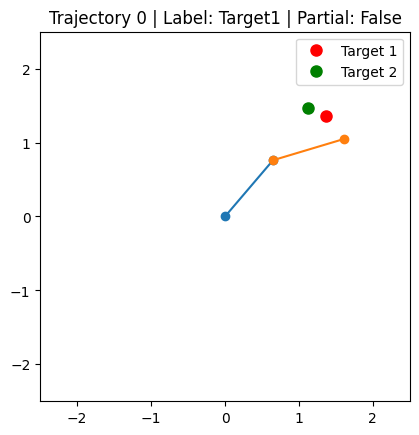

In [19]:
%matplotlib inline

# Example: Animate the first few trajectories
unique_ids = df['trajectory_id'].unique()

# Animate one full and one partial trajectory, for demonstration:
animate_trajectory(df, unique_ids[0], interval=300)

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

def extract_features(df):
    """
    Convert the time-series DataFrame into a per-trajectory feature set.
    For simplicity, let's just use the final (x, y) of each trajectory + average direction.
    """
    features = []
    labels = []

    for traj_id in df['trajectory_id'].unique():
        subset = df[df['trajectory_id'] == traj_id].sort_values(by='time_step')
        label = subset['label'].iloc[0]
        is_partial = subset['is_partial'].iloc[0]

        # final position
        x_final = subset['x_ee'].iloc[-1]
        y_final = subset['y_ee'].iloc[-1]

        # average direction (dx, dy)
        x_init = subset['x_ee'].iloc[0]
        y_init = subset['y_ee'].iloc[0]

        dx_total = x_final - x_init
        dy_total = y_final - y_init

        # Let's store some features
        features.append([x_final, y_final, dx_total, dy_total, is_partial])
        labels.append(label)

    return np.array(features), np.array(labels)

In [22]:
# Convert data into features
X, y = extract_features(df)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.3f}")


# Get indices of partial and full trajectories in the test set
partial_indices = X_test[:, -1] == 1  # Assuming is_partial is the last feature
full_indices = ~partial_indices       # Inverted for full trajectories

# Calculate accuracy for partial trajectories
accuracy_partial = clf.score(X_test[partial_indices], y_test[partial_indices])

# Calculate accuracy for full trajectories
accuracy_full = clf.score(X_test[full_indices], y_test[full_indices])

# Print both accuracies
print(f"Test Accuracy (Partial): {accuracy_partial:.3f}")
print(f"Test Accuracy (Full): {accuracy_full:.3f}")

Test Accuracy: 0.806
Test Accuracy (Partial): 0.732
Test Accuracy (Full): 0.865


Try out:

*   Plot a figure showing how accuracy is depending on degree of partiality or distance between targets
*   Different classification models (look at the scikit-learn website)
* Engineer new feautures



